In [1]:
 import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Step 1: Load and inspect dataset
data  = pd.read_csv('/content/drive/MyDrive/CFYLD.csv', encoding='latin1')

In [3]:
# View first rows
data.head()

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),Fertilizers,Soil Type,ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
0,2001,10982.256830,6.27,0.106,11.22,140.8,1.11,yes,Loamy-sand,32.81,1.26,47.35,4.72,21.75,0.59,2388.0
1,2005,5114.989137,6.16,0.191,11.28,347.3,1.88,yes,Sandy-clay,35.93,2.03,52.48,3.47,21.81,0.64,879.8
2,2005,7894.569177,5.40,0.061,10.85,306.6,0.71,yes,Red sandy-loam,34.87,3.28,65.54,3.51,22.98,0.63,1520.4
3,2010,5361.182751,5.68,0.092,10.98,466.2,1.15,yes,Sandy-clay,34.83,1.88,61.67,9.03,22.15,0.41,1302.6
4,2014,7255.211262,5.81,0.111,13.12,524.1,1.45,yes,Sandy-clay,33.96,2.66,55.44,5.46,22.83,0.52,1115.1


In [4]:
# Check shape (rows, columns)
data.shape

(500, 16)

In [5]:
# Column names
data.columns

Index(['Year', 'Area(hec)', 'pH', 'Tot. N (%)', 'Avail. P (ppm)',
       'Exch. K (ppm)', 'Org. C (%)', 'Fertilizers', 'Soil Type',
       'ANN_Temperature', 'Precipitation(mm/day)', 'Relative_humidity',
       'ANN_ Wind Speed(m/s)', 'Solar_radiation(MJ/mÂ²/day)', 'Soil wetness',
       'Yeild(tone/hect)'],
      dtype='object')

In [6]:
data.describe()

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2007.674000,11134.119884,5.830520,0.128852,11.153820,304.082800,1.198600,34.471400,2.510280,55.540680,5.807520,22.244720,0.554760,2515.853600
std,4.802693,3971.363509,0.482003,0.039617,2.241483,157.352487,0.396071,1.450543,0.852354,6.132361,2.035295,0.731636,0.086644,1219.051845
min,2000.000000,4202.352207,5.000000,0.060000,7.000000,91.400000,0.510000,32.000000,1.110000,45.000000,2.310000,21.000000,0.400000,518.200000
25%,2003.000000,7789.829915,5.430000,0.093000,9.285000,147.575000,0.867500,33.160000,1.727500,50.362500,4.075000,21.597500,0.480000,1631.775000
50%,2007.000000,10971.602425,5.815000,0.132000,11.170000,319.200000,1.190000,34.465000,2.530000,55.665000,5.680000,22.230000,0.560000,2383.400000
75%,2012.000000,13993.562982,6.240000,0.161000,13.062500,425.050000,1.520000,35.732500,3.270000,60.915000,7.662500,22.892500,0.630000,3256.975000
max,2015.000000,20603.301070,6.690000,0.200000,14.990000,597.000000,1.890000,37.000000,4.000000,65.940000,9.400000,23.500000,0.700000,6509.000000


In [7]:
data.describe(include='all')

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),Fertilizers,Soil Type,ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,Volcanic clay-loam,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,469,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2007.674000,11134.119884,5.830520,0.128852,11.153820,304.082800,1.198600,NaN,NaN,34.471400,2.510280,55.540680,5.807520,22.244720,0.554760,2515.853600
std,4.802693,3971.363509,0.482003,0.039617,2.241483,157.352487,0.396071,NaN,NaN,1.450543,0.852354,6.132361,2.035295,0.731636,0.086644,1219.051845
min,2000.000000,4202.352207,5.000000,0.060000,7.000000,91.400000,0.510000,NaN,NaN,32.000000,1.110000,45.000000,2.310000,21.000000,0.400000,518.200000
25%,2003.000000,7789.829915,5.430000,0.093000,9.285000,147.575000,0.867500,NaN,NaN,33.160000,1.727500,50.362500,4.075000,21.597500,0.480000,1631.775000
50%,2007.000000,10971.602425,5.815000,0.132000,11.170000,319.200000,1.190000,NaN,NaN,34.465000,2.530000,55.665000,5.680000,22.230000,0.560000,2383.400000
75%,2012.000000,13993.562982,6.240000,0.161000,13.062500,425.050000,1.520000,NaN,NaN,35.732500,3.270000,60.915000,7.662500,22.892500,0.630000,3256.975000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         500 non-null    int64  
 1   Area(hec)                    500 non-null    float64
 2   pH                           500 non-null    float64
 3   Tot. N (%)                   500 non-null    float64
 4   Avail. P (ppm)               500 non-null    float64
 5   Exch. K (ppm)                500 non-null    float64
 6   Org. C (%)                   500 non-null    float64
 7   Fertilizers                  500 non-null    object 
 8   Soil Type                    500 non-null    object 
 9   ANN_Temperature              500 non-null    float64
 10  Precipitation(mm/day)        500 non-null    float64
 11  Relative_humidity            500 non-null    float64
 12  ANN_ Wind Speed(m/s)         500 non-null    float64
 13  Solar_radiation(MJ/m

In [ ]:
data['Fertilizers'] = data['Fertilizers'].map({'yes': 1, 'no': 0})
data['Fertilizers'] = data['Fertilizers'].fillna(0)

In [ ]:
# Step 3: Define features and target
X = data.drop(columns=['Yeild(tone/hect)', 'Year'])  # drop 'Year' if not useful
y = data['Yeild(tone/hect)']

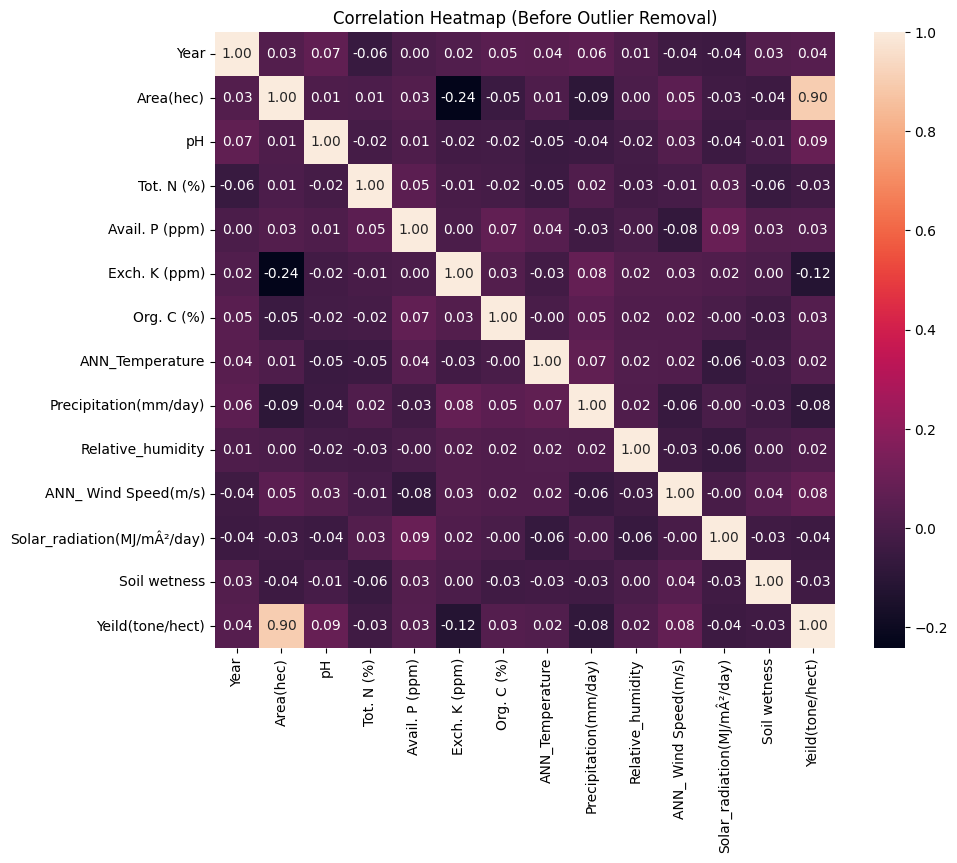

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (important for heatmap)
num_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_data.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Before Outlier Removal)")
plt.show()

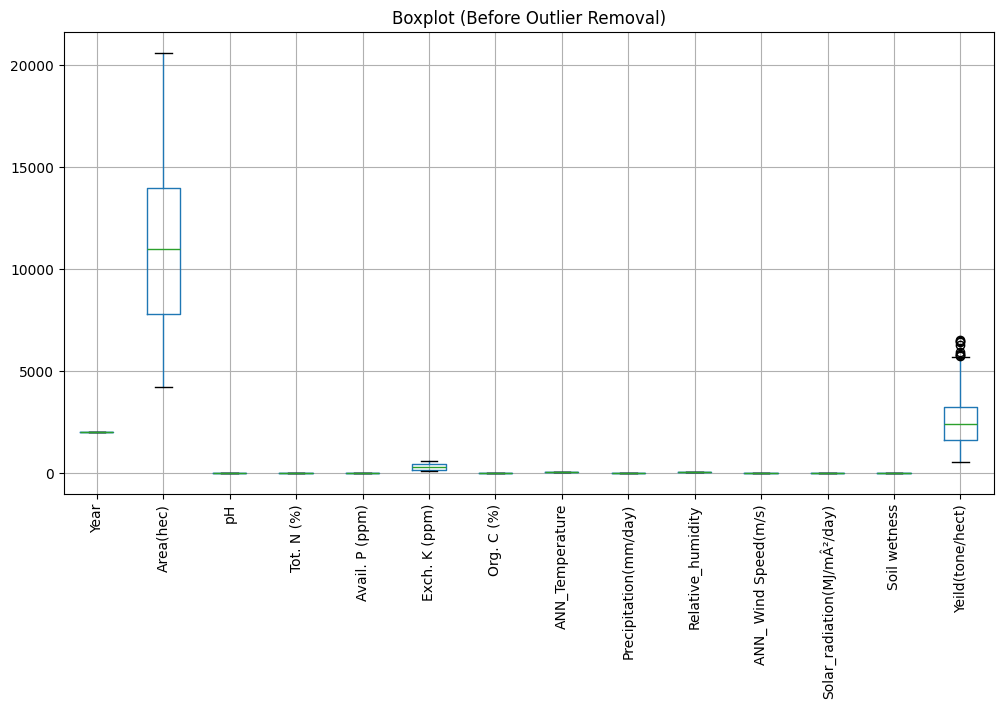

In [14]:
plt.figure(figsize=(12,6))
num_data.boxplot(rot=90)
plt.title("Boxplot (Before Outlier Removal)")
plt.show()

In [ ]:
# Step 3: Outlier removal using IQR
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
Q1 = X[numerical_cols].quantile(0.25)
Q3 = X[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
filter_mask = ~((X[numerical_cols] < (Q1 - 1.5 * IQR)) | (X[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
X = X[filter_mask]
y = y[filter_mask]


In [ ]:
# Optional check for Fertilizers column
print(data['Fertilizers'].value_counts(dropna=False))
print(data['Fertilizers'].isnull().sum())

Fertilizers
1    469
0     31
Name: count, dtype: int64
0


In [ ]:
# Step 5: Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Step 6: Identify column types based on training data
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
# Step 7: Define the preprocessing pipeline

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [ ]:
 # Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (375, 14)
Shape of X_test: (94, 14)
Shape of y_train: (375,)
Shape of y_test: (94,)


In [ ]:
data.shape

(500, 16)

In [ ]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 375 samples
Testing set size: 94 samples


In [ ]:
#  Models
models = {
    'ElasticNet': ElasticNet(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'Ridge': Ridge(random_state=42),
    'GBoost': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

In [ ]:
# Train model train (default) and perform 5-fold CV
from collections import defaultdict
train_results = defaultdict(dict)
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    # Train model train
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline



In [ ]:
    # Perform 5-fold CV on training data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    train_results[name]['CV R2 Mean'] = cv_scores.mean()
    train_results[name]['CV R2 Std'] = cv_scores.std()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

train_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    train_results[name] = {
        'Mean R²': scores.mean(),
        'Std R²': scores.std()
    }
# Display model train CV results
train_results_df = pd.DataFrame(train_results).T.round(4)
train_results_df = train_results_df.sort_values(by='Mean R²', ascending=False)

print("\nModel Train 5-Fold Cross-Validation Results (Training Data):")
print(train_results_df)



Model Train 5-Fold Cross-Validation Results (Training Data):
              Mean R²  Std R²
Ridge          0.8215  0.0490
GBoost         0.8167  0.0372
RandomForest   0.8074  0.0442
XGBoost        0.7791  0.0414
ElasticNet     0.7468  0.0351
SVR           -0.0164  0.0361


In [ ]:
# Define refined hyperparameter grids for GridSearchCV
param_grids = {
    'ElasticNet': {
        'regressor__alpha': [0.01, 0.03, 0.05, 0.07, 0.09],
         'regressor__l1_ratio': [0.4, 0.5, 0.6, 0.7],
        'regressor__max_iter': [10000],
        'regressor__tol': [1e-4]
    },
    'Ridge': {
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0],
        'regressor__fit_intercept': [True],
        'regressor__solver': ['auto', 'saga'],
        'regressor__max_iter':  [3000, 5000],
        'regressor__tol': [1e-3, 1e-4],
    },
    'RandomForest': {
        'regressor__n_estimators': [400, 500],
        'regressor__max_depth': [6, 8],
        'regressor__min_samples_split': [5, 7],
        'regressor__min_samples_leaf': [4, 5],
        'regressor__max_features': ['sqrt', 0.2]

    },

    'XGBoost': {
    'regressor__n_estimators': [300, 400],
    'regressor__max_depth': [4, 5],
    'regressor__learning_rate': [0.02, 0.03],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.7],
},
    'GBoost': {
        'regressor__n_estimators': [300, 350],
        'regressor__learning_rate': [0.03, 0.035],
        'regressor__max_depth': [3, 4],
        'regressor__subsample': [0.9],
        'regressor__min_samples_split': [5, 7],
        'regressor__min_samples_leaf': [4, 5]
    },
    'SVR': {
        'regressor__C': [300, 350, 400],
        'regressor__epsilon': [0.03, 0.04, 0.05],
        'regressor__gamma': ['scale'],
        'regressor__kernel': ['linear']
    }
}


In [ ]:
#  Tune all models using GridSearchCV on training data
results = {}
best_models = {}
feature_importances = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name} with GridSearchCV...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    try:
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=5,
            scoring='r2',
            refit=True,
            n_jobs=-1 if name != 'XGBoost' else 1,
            verbose=1
        )
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        results[name] = {
            'Best Params': search.best_params_,
            'CV R2': search.best_score_
        }
        # Store feature importances for tree-based models
        if name in ['RandomForest', 'GBoost', 'XGBoost']:
            feature_importances[name] = search.best_estimator_.named_steps['regressor'].feature_importances_
    except Exception as e:
        print(f"⚠️ Failed to tune {name}: {str(e)}")
        results[name] = {'Error': str(e), 'Model': None}



🔍 Tuning ElasticNet with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🔍 Tuning RandomForest with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning SVR with GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

🔍 Tuning Ridge with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning GBoost with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning XGBoost with GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
# Display GridSearchCV tuning results
tuning_results_df = pd.DataFrame(results).T
tuning_results_df = tuning_results_df.dropna().sort_values(by='CV R2', ascending=False)
tuning_results_df['CV R2'] = tuning_results_df['CV R2'].round(4)
print("\n🎯 GridSearchCV Tuning Results (Training Data, 5-fold CV):")
print(tuning_results_df)


🎯 GridSearchCV Tuning Results (Training Data, 5-fold CV):
                                                    Best Params     CV R2
GBoost        {'regressor__learning_rate': 0.03, 'regressor_...  0.826707
ElasticNet    {'regressor__alpha': 0.09, 'regressor__l1_rati...  0.822787
Ridge         {'regressor__alpha': 10.0, 'regressor__fit_int...  0.822775
SVR           {'regressor__C': 350, 'regressor__epsilon': 0....  0.822148
XGBoost       {'regressor__colsample_bytree': 0.7, 'regresso...  0.818649
RandomForest  {'regressor__max_depth': 8, 'regressor__max_fe...  0.797488


In [ ]:
# Evaluate all tuned models on the test set (only once)
final_results = defaultdict(dict)
y_preds = {}  # Initialize y_preds dictionary
for name, model in best_models.items():
    if model is not None:
        y_pred = model.predict(X_test)
        final_results[name]['Test RMSE'] = np.sqrt(mean_squared_error(y_test, y_pred))
        final_results[name]['Test MAE'] = mean_absolute_error(y_test, y_pred)
        final_results[name]['Test R2'] = r2_score(y_test, y_pred)
        final_results[name]['CV R2'] = results[name]['CV R2']
        final_results[name]['Best Params'] = results[name]['Best Params']


In [ ]:
#  Report final results
final_results_df = pd.DataFrame(final_results).T
if 'Test R2' in final_results_df.columns:
    final_results_df_sorted = final_results_df.sort_values(by='Test R2', ascending=False)
    print("\n Final Tuned Model Performance (Test Set):")
    print(final_results_df_sorted[['Test R2', 'Test RMSE', 'Test MAE', 'CV R2']])
    best_model_name = final_results_df_sorted.index[0]
    print(f"\n🌟 Best Model: {best_model_name}")
    print(f"Best Parameters:\n{final_results_df_sorted.loc[best_model_name, 'Best Params']}")


 Final Tuned Model Performance (Test Set):
               Test R2   Test RMSE    Test MAE     CV R2
Ridge         0.843067  519.366459  377.487576  0.822775
ElasticNet     0.84173  521.575444  378.539536  0.822787
SVR           0.839959  524.485214  385.938184  0.822148
GBoost        0.837733  528.119425  382.465668  0.826707
XGBoost       0.828123  543.533782   398.26963  0.818649
RandomForest  0.763547  637.514691  462.953528  0.797488

🌟 Best Model: Ridge
Best Parameters:
{'regressor__alpha': 10.0, 'regressor__fit_intercept': True, 'regressor__max_iter': 3000, 'regressor__solver': 'saga', 'regressor__tol': 0.0001}


In [ ]:
# Display feature importances for all models
feature_names = (numeric_cols +
                 list(best_models[list(best_models.keys())[0]].named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_cols)))

for name in models.keys():
    if name in feature_importances:
        print(f"\nFeature Importances for {name}:")
        importances = pd.Series(feature_importances[name], index=feature_names).sort_values(ascending=False)
        print(importances.head(12))  # Top 10 features


Feature Importances for RandomForest:
Area(hec)                       0.416786
Soil Type_Sandy-clay            0.156168
Soil Type_Brown clay            0.155134
Exch. K (ppm)                   0.074040
Soil Type_Red sandy-loam        0.029577
Precipitation(mm/day)           0.021316
Relative_humidity               0.017952
pH                              0.017948
Soil Type_Volcanic clay-loam    0.015187
ANN_Temperature                 0.014294
ANN_ Wind Speed(m/s)            0.013113
Org. C (%)                      0.012424
dtype: float64

Feature Importances for GBoost:
Area(hec)                0.829047
pH                       0.032349
Exch. K (ppm)            0.023280
Soil Type_Brown clay     0.018769
ANN_ Wind Speed(m/s)     0.012633
Org. C (%)               0.011823
Precipitation(mm/day)    0.011548
Relative_humidity        0.010511
ANN_Temperature          0.009376
Soil Type_Sandy-clay     0.009013
Tot. N (%)               0.007881
Soil wetness             0.006458
dtype: float6

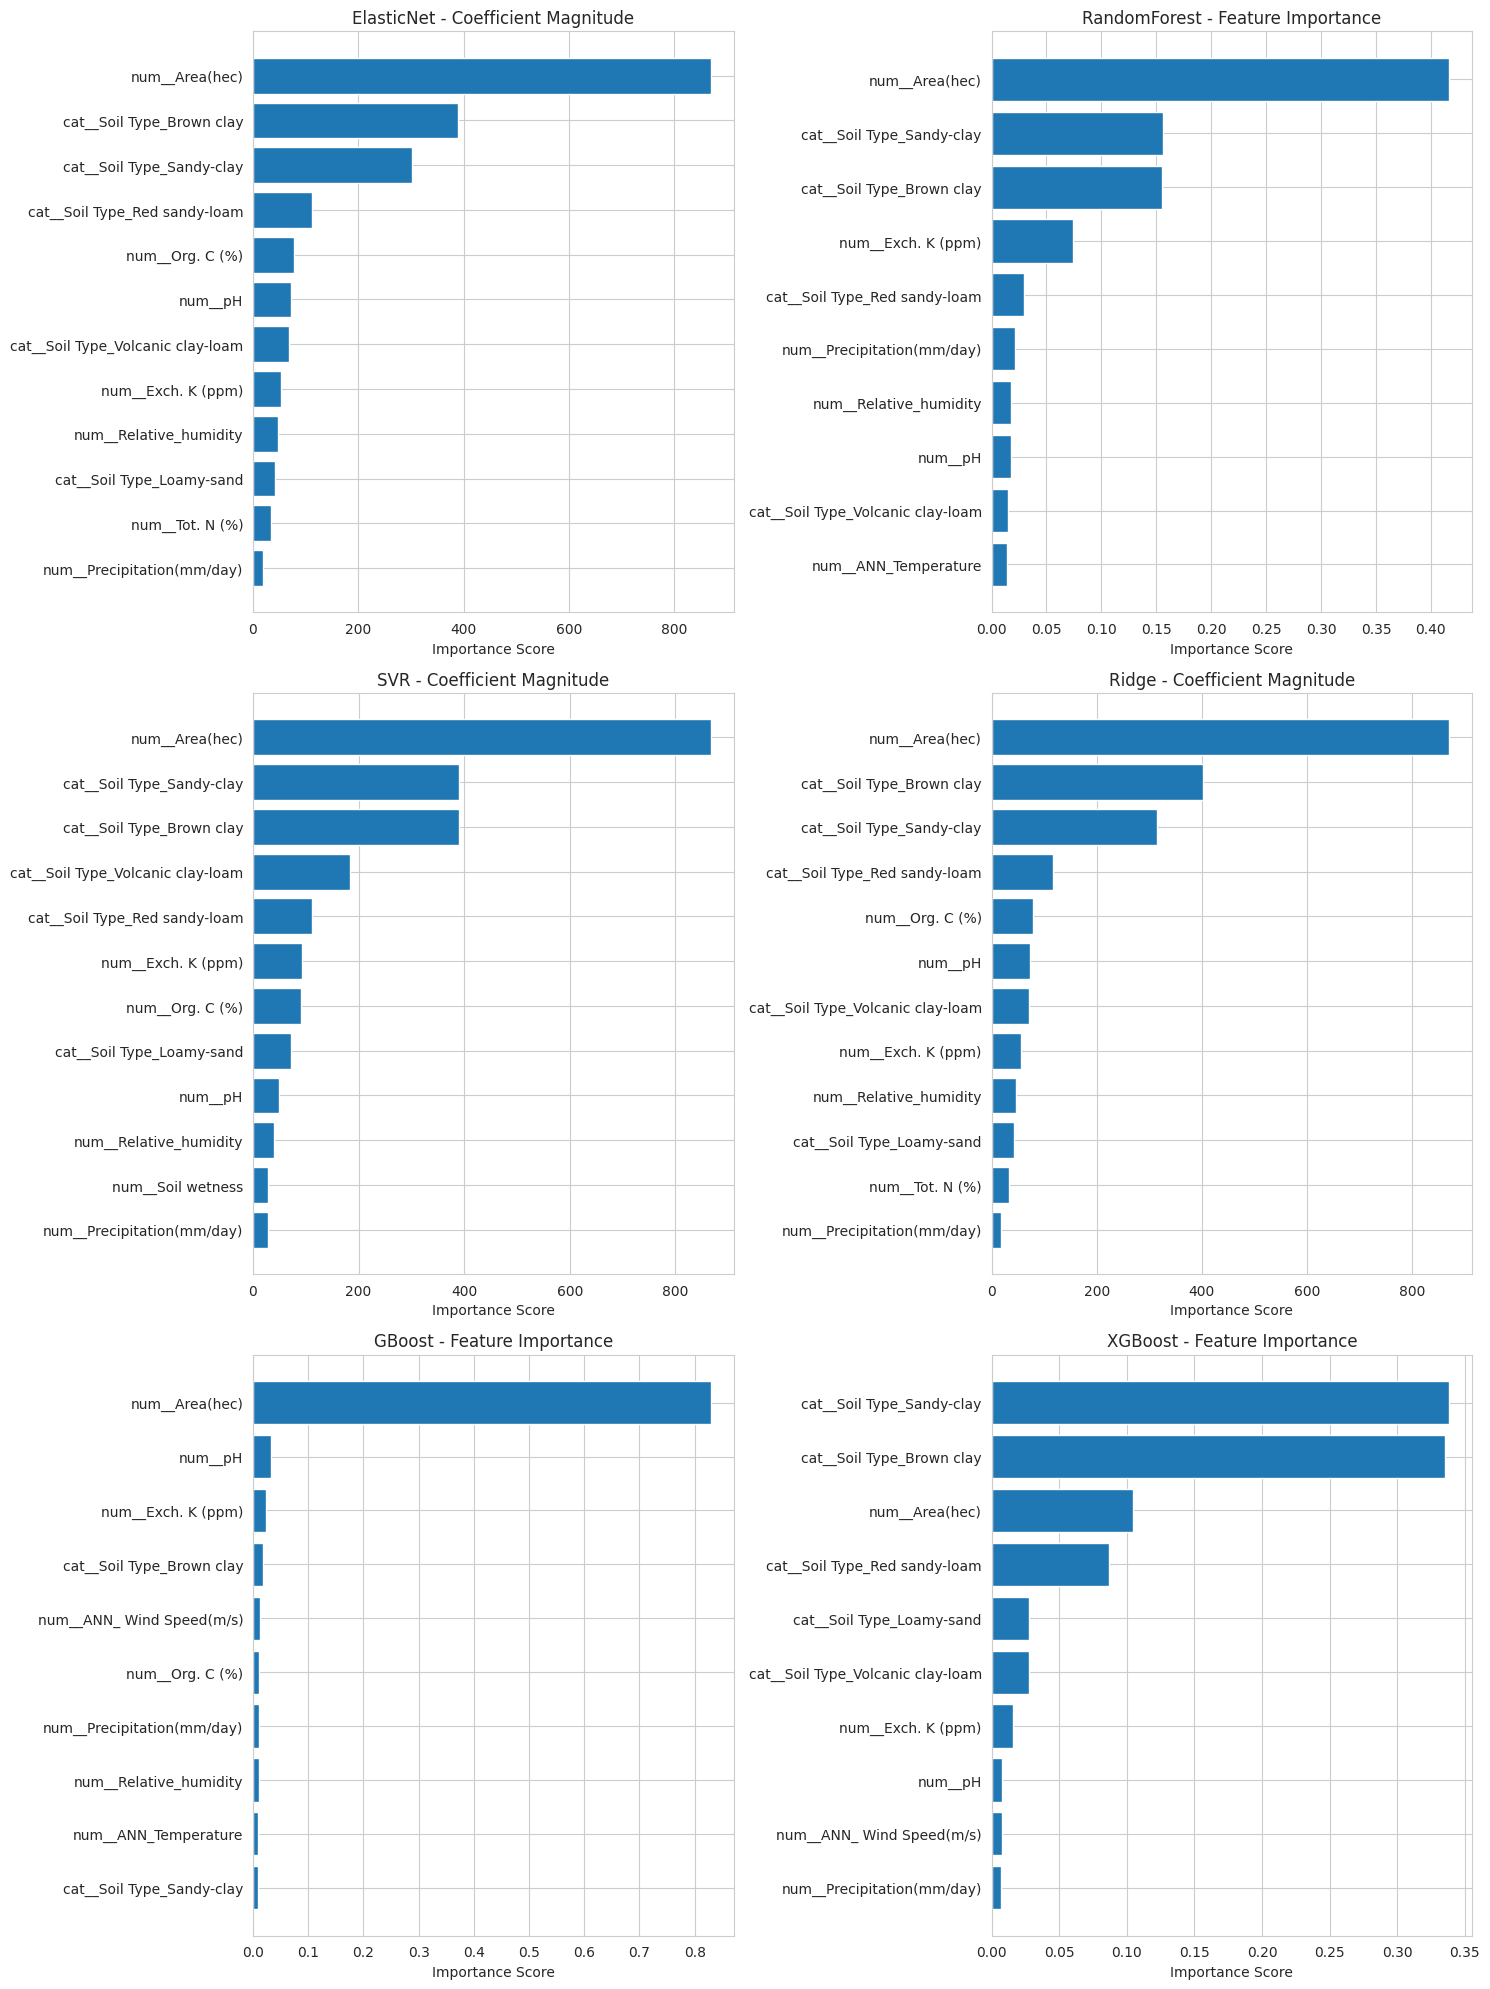

In [ ]:
plt.figure(figsize=(15, 20))
sns.set_style("whitegrid")

for i, (name, model) in enumerate(best_models.items(), 1):
    plt.subplot(3, 2, i)

    # Get feature names from the pipeline
    try:
        feature_names = model.named_steps['preprocessor'].get_feature_names_out()
    except AttributeError:
        # Fallback for older sklearn versions or different preprocessors
        numeric_features = X_train.select_dtypes(include=['number']).columns
        categorical_features = X_train.select_dtypes(include=['object', 'category']).columns
        feature_names = numeric_features.tolist() + \
                      [f"{col}_{val}" for col in categorical_features
                       for val in model.named_steps['preprocessor'].named_transformers_['cat'].categories_[
                           list(categorical_features).index(col)]]

    if name in ['RandomForest', 'GBoost', 'XGBoost']:
        # Tree-based feature importances
        importances = model.named_steps['regressor'].feature_importances_
        # Handle case where importances might be 2D
        if len(importances.shape) > 1:
            importances = importances.mean(axis=0)
        top_n = min(10, len(importances))
        indices = np.argsort(importances)[-top_n:]
        plt.title(f'{name} - Feature Importance')
        plt.barh(range(len(indices)), importances[indices], align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

    elif name in ['Ridge', 'ElasticNet', 'SVR']:
        # Linear model coefficients
        coef = model.named_steps['regressor'].coef_
        if len(coef.shape) > 1:  # For multi-output
            coef = coef[0]
        top_n = min(12, len(coef))
        indices = np.argsort(np.abs(coef))[-top_n:]
        plt.title(f'{name} - Coefficient Magnitude')
        plt.barh(range(len(indices)), np.abs(coef[indices]), align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

    plt.xlabel('Importance Score')
    plt.tight_layout()

plt.show()

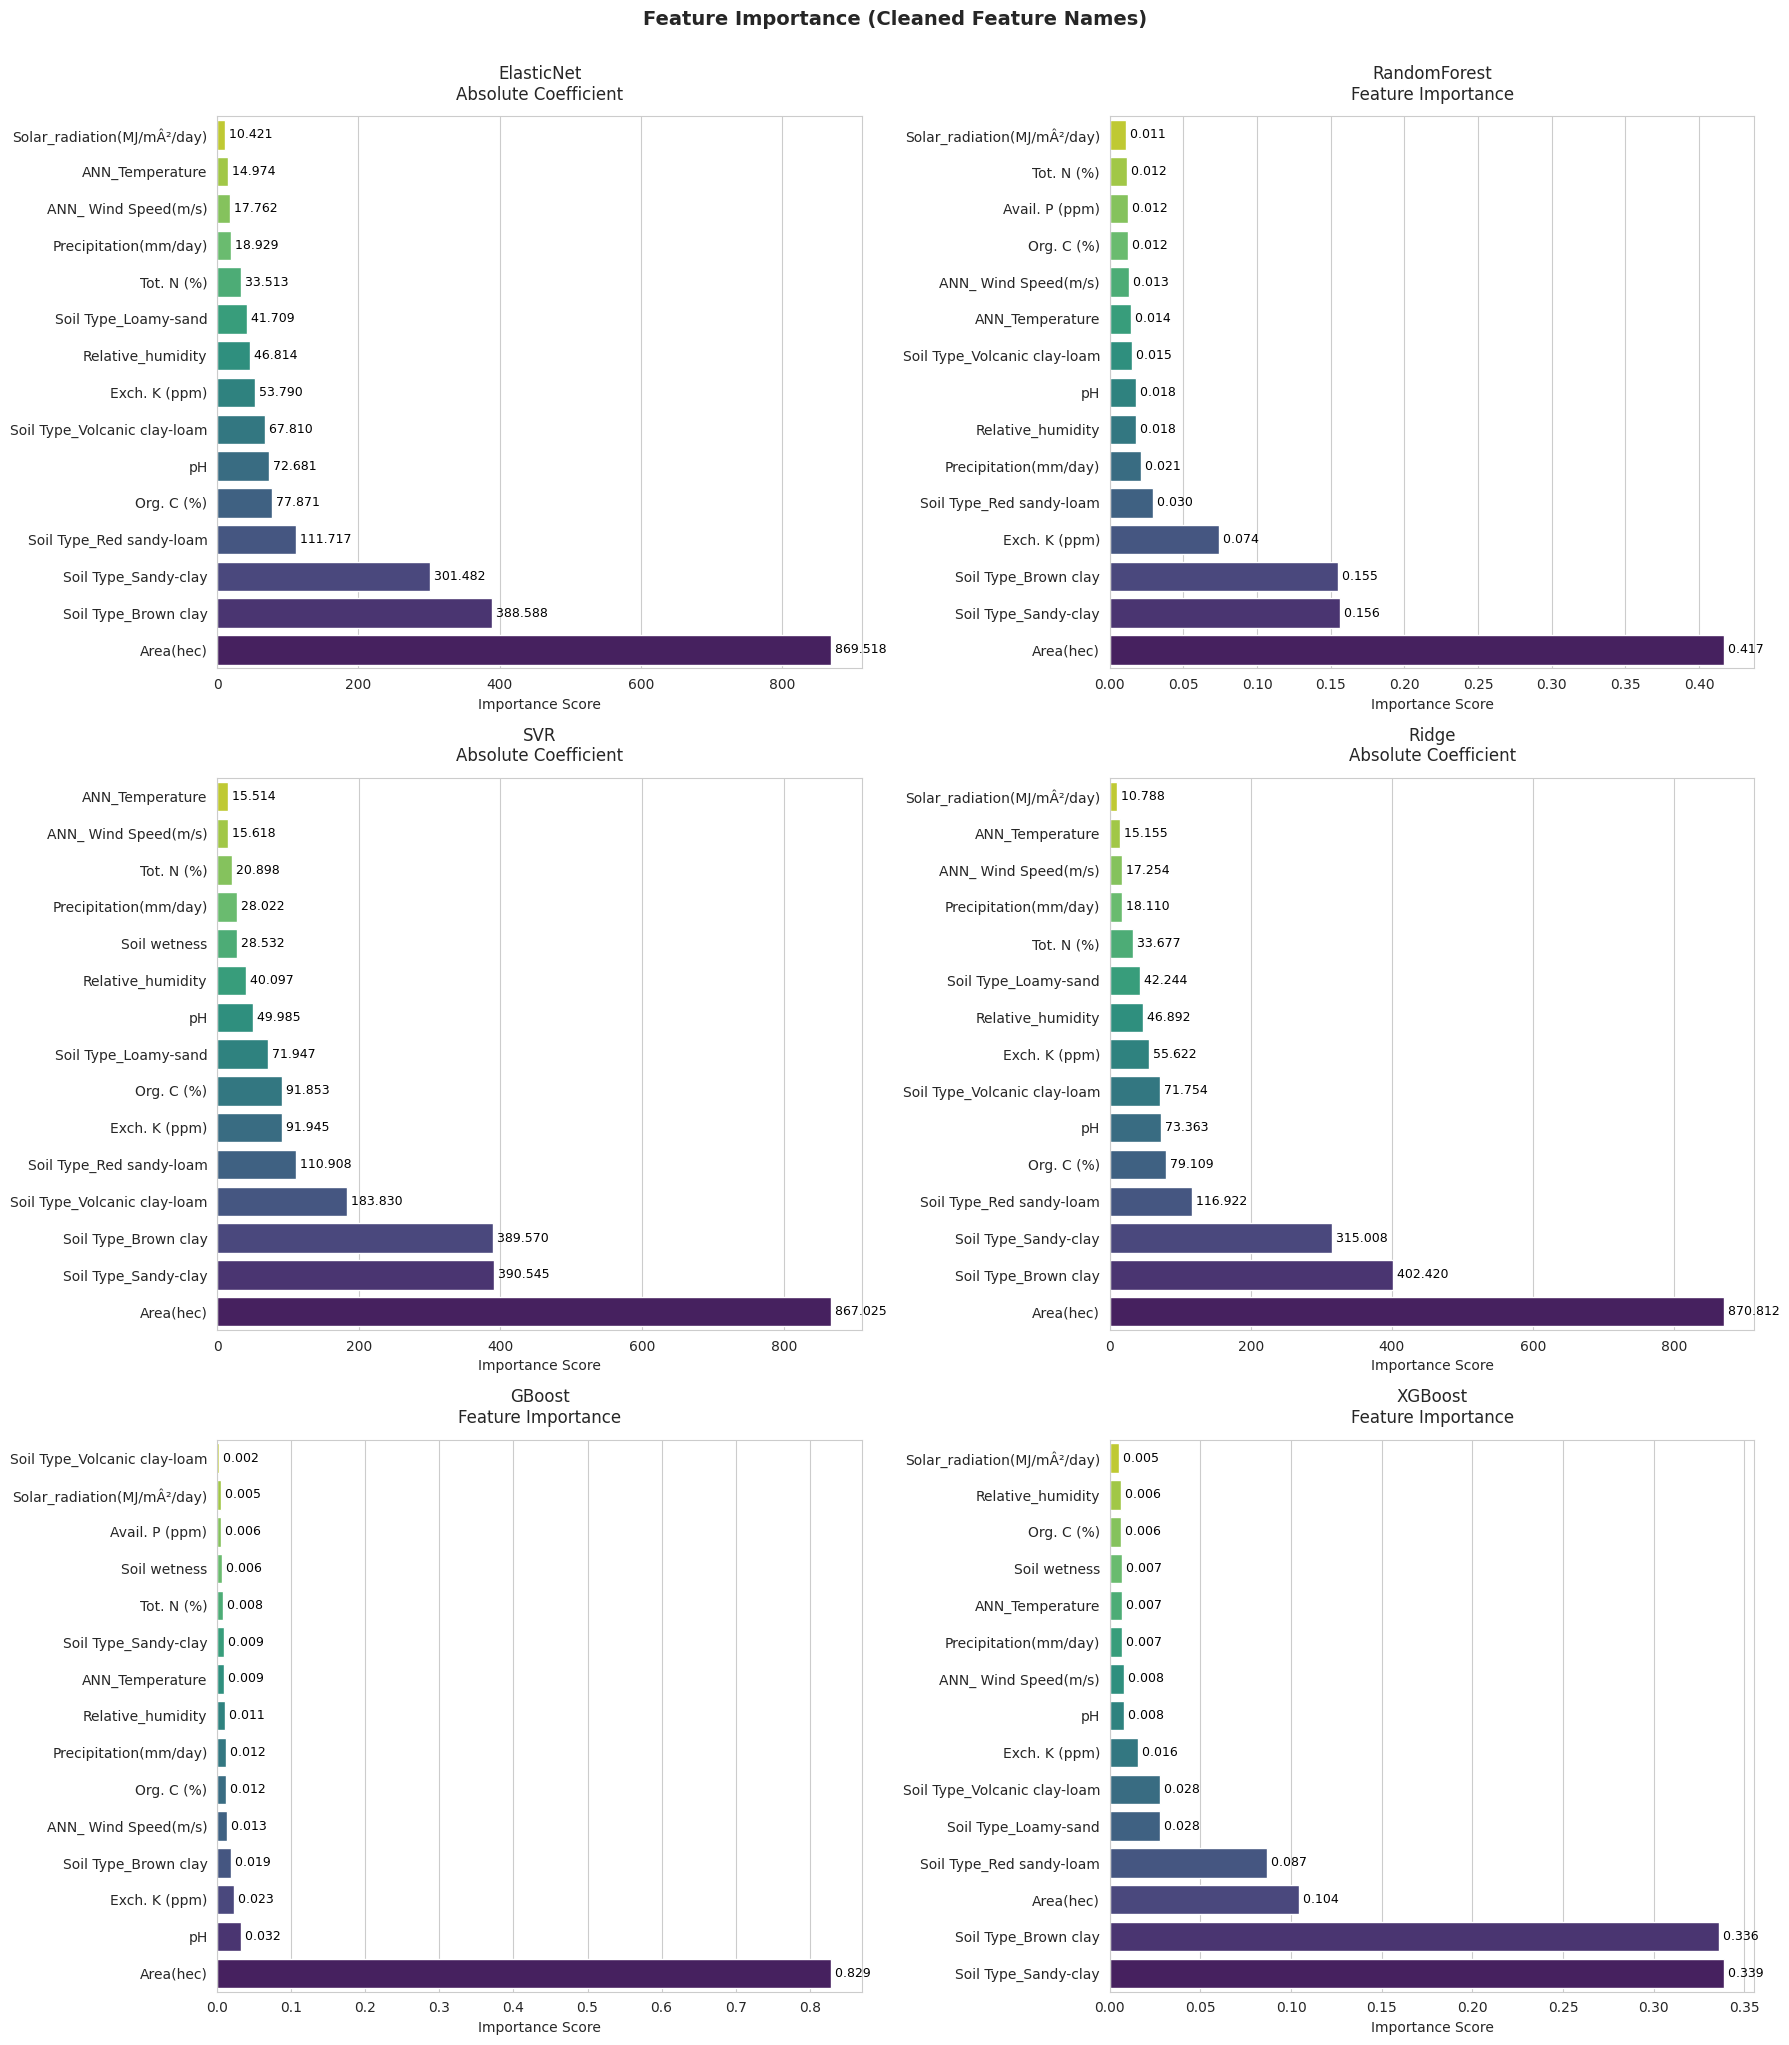

In [ ]:
plt.figure(figsize=(18, 20))
sns.set_style("whitegrid")

# Get cleaned feature names (remove sklearn's auto-added prefixes)
feature_names = []
for name in best_models['Ridge'].named_steps['preprocessor'].get_feature_names_out():
    # Remove 'num__' or 'cat__' prefixes added by sklearn
    if name.startswith('num__'):
        feature_names.append(name[5:])  # Remove 'num__'
    elif name.startswith('cat__'):
        feature_names.append(name[5:])  # Remove 'cat__'
    else:
        feature_names.append(name)

# Create subplots for each model
for i, (name, model) in enumerate(best_models.items(), 1):
    plt.subplot(3, 2, i)

    # Get feature importances/coefficients
    if name in ['Ridge', 'ElasticNet', 'SVR']:
        coef = model.named_steps['regressor'].coef_
        if len(coef.shape) > 1:
            coef = coef[0]
        importances = np.abs(coef)
        importance_type = "Absolute Coefficient"
    else:
        importances = model.named_steps['regressor'].feature_importances_
        importance_type = "Feature Importance"

    # Sort and select top features
    indices = np.argsort(importances)[-15:]  # Top 15 features
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    # Horizontal bar plot
    ax = sns.barplot(x=sorted_importances,
                    y=sorted_features,
                    hue=sorted_features,  # Proper hue assignment
                    palette="viridis_r",
                    orient='h',
                    dodge=False,
                    legend=False)

    # Annotations
    plt.title(f"{name}\n{importance_type}", fontsize=12, pad=12)
    plt.xlabel("Importance Score", fontsize=10)
    plt.ylabel("")

    # Add value labels
    for j, v in enumerate(sorted_importances):
        ax.text(v, j, f" {v:.3f}", color='black', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle("Feature Importance (Cleaned Feature Names)", y=1.02, fontsize=14, weight='bold')
plt.show()

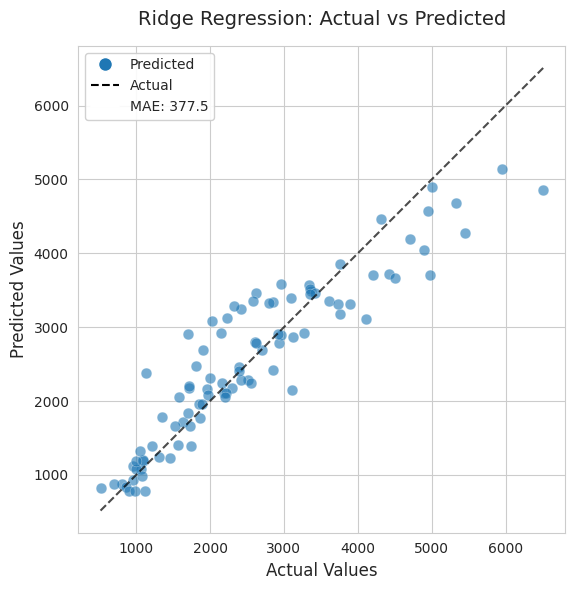

In [ ]:
# Focus on Ridge model only
name = 'Ridge'
model = best_models[name]
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Scatter plot (Predicted values)
ax = sns.scatterplot(x=y_test, y=y_pred,
                    alpha=0.6,
                    color='#1f77b4',  # Consistent blue
                    edgecolor='w',
                    linewidth=0.3,
                    s=60,
                    label='Predicted')

# Perfect prediction line (Actual values)
val_range = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
plt.plot(val_range, val_range, 'k--',
         linewidth=1.5,
         alpha=0.7,
         label='Actual')

# Custom legend with MAE
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
          label='Predicted',
          markerfacecolor='#1f77b4', markersize=10),
    Line2D([0], [0], color='k', linestyle='--',
          label='Actual',
          linewidth=1.5),
    Line2D([0], [0], marker='', color='w',
          label=f'MAE: {mae:.1f}',
          markerfacecolor='white')
]

plt.legend(handles=legend_elements,
          loc='upper left',
          frameon=True,
          framealpha=0.9)

# Titles and labels
plt.title(f'{name} Regression: Actual vs Predicted', fontsize=14, pad=15)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

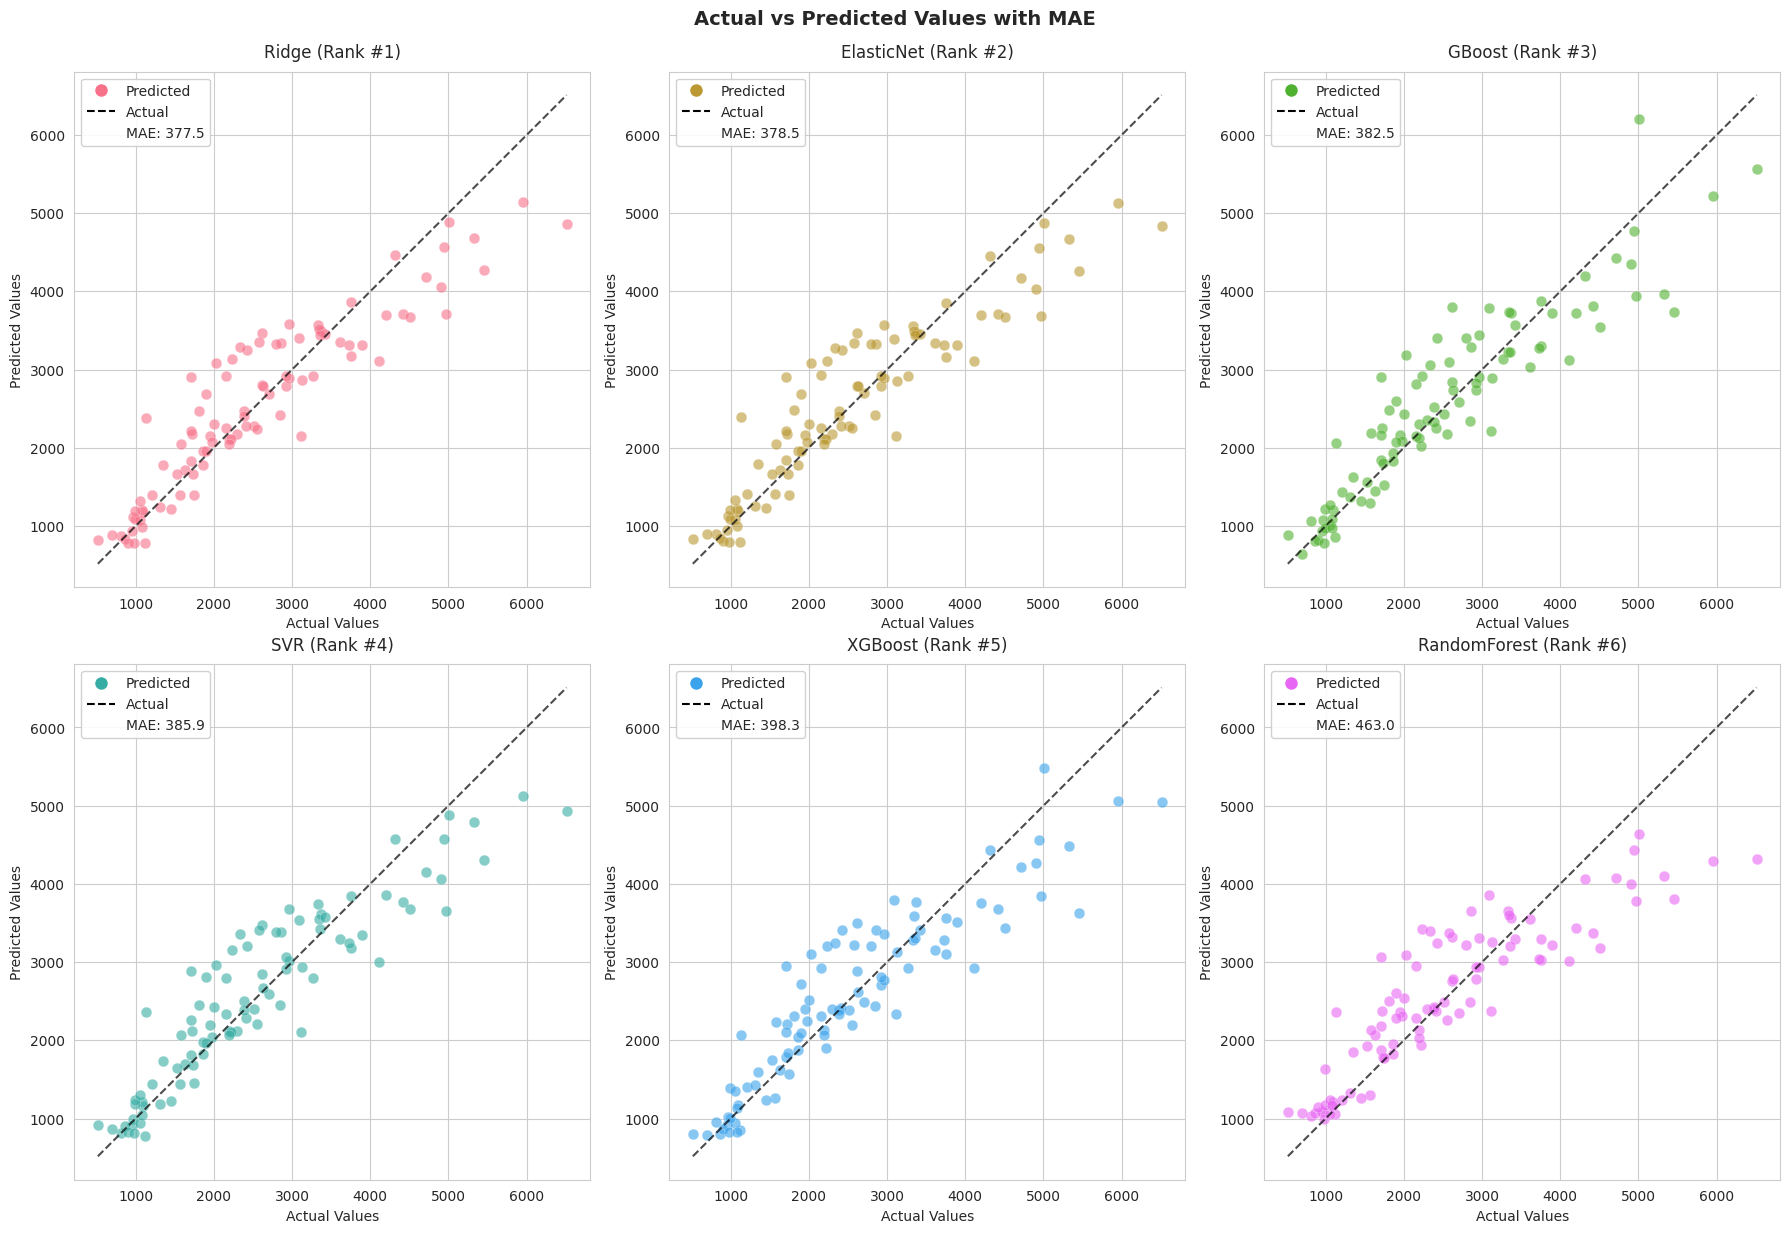

In [ ]:
plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# Use a consistent color palette
palette = sns.color_palette("husl", len(best_models))

# Order models by MAE (best to worst)
model_mae = {name: mean_absolute_error(y_test, best_models[name].predict(X_test))
             for name in best_models}
model_order = sorted(model_mae.keys(), key=lambda x: model_mae[x])

for i, name in enumerate(model_order, 1):
    plt.subplot(2, 3, i)
    model = best_models[name]
    y_pred = model.predict(X_test)
    mae = model_mae[name]

    # Scatter plot with consistent color
    ax = sns.scatterplot(x=y_test, y=y_pred,
                        alpha=0.6,
                        color=palette[i-1],
                        edgecolor='w',
                        linewidth=0.3,
                        s=60,
                        label='Predicted')

    # Perfect prediction line (Actual)
    val_range = [min(y_test.min(), y_pred.min()),
                max(y_test.max(), y_pred.max())]
    actual_line = plt.plot(val_range, val_range, 'k--',
                         linewidth=1.5,
                         alpha=0.7,
                         label='Actual')

    # Create custom legend elements
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
              label='Predicted',
              markerfacecolor=palette[i-1], markersize=10),
        Line2D([0], [0], color='k', linestyle='--',
              label='Actual',
              linewidth=1.5),
        Line2D([0], [0], marker='', color='w',
              label=f'MAE: {mae:.1f}',
              markerfacecolor='white')
    ]

    # Position legend
    plt.legend(handles=legend_elements,
              loc='upper left',
              frameon=True,
              framealpha=0.9)

    # Model name and axes
    plt.title(f"{name} (Rank #{i})", fontsize=12, pad=10)
    plt.xlabel('Actual Values', fontsize=10)
    plt.ylabel('Predicted Values', fontsize=10)

    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.suptitle('Actual vs Predicted Values with MAE',
             y=1.02, fontsize=14, weight='bold')
plt.show()

========================================================================================